# Trader Performance vs Market Sentiment — Primetrade.ai Assignment
**Author:** Submitted for Data Science / Analytics Intern Role  
**Datasets:** Bitcoin Fear/Greed Index + Hyperliquid Historical Trades  

---
## Methodology Summary
1. **Data Preparation** — Load, clean, align datasets at daily level  
2. **Analysis** — Sentiment vs PnL, behaviour shifts, trader segmentation  
3. **Insights** — 4 evidence-backed findings  
4. **Strategy Recommendations** — 2 actionable rules of thumb  
5. **Bonus** — Random Forest profitability classifier + KMeans behavioural archetypes  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, kruskal

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded")

Libraries loaded


In [2]:
fg = pd.read_csv("/kaggle/input/datasets/veerkukreti/traders/fear_greed_index.csv")
hd = pd.read_csv("/kaggle/input/datasets/veerkukreti/traders/historical_data.csv")

print("Fear/Greed shape:", fg.shape)
print("Trader data shape:", hd.shape)

fg.head()

Fear/Greed shape: (2644, 4)
Trader data shape: (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
# Convert Fear Greed timestamp (seconds)
fg["date"] = pd.to_datetime(fg["timestamp"], unit="s").dt.normalize()

# Convert trader timestamp (milliseconds)
hd["datetime"] = pd.to_datetime(hd["Timestamp"], unit="ms")
hd["date"] = hd["datetime"].dt.normalize()

print("Trader date range:", hd["date"].min(), "→", hd["date"].max())
print("FG date range:", fg["date"].min(), "→", fg["date"].max())

Trader date range: 2023-03-28 00:00:00 → 2025-06-15 00:00:00
FG date range: 2018-02-01 00:00:00 → 2025-05-02 00:00:00


In [4]:
fg_slim = fg[["date","value","classification"]].drop_duplicates("date")

df = hd.merge(fg_slim, on="date", how="inner")

print("Merged rows:", len(df))
print("Unique traders:", df["Account"].nunique())

df["classification"].value_counts()

Merged rows: 184263
Unique traders: 32


classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

In [5]:
df["is_win"] = df["Closed PnL"] > 0
df["is_long"] = df["Side"].str.upper() == "BUY"
df["net_pnl"] = df["Closed PnL"] - df["Fee"]

In [6]:
daily = (
    df.groupby(["Account","date","classification","value"])
    .agg(
        total_trades=("Trade ID","count"),
        daily_pnl=("net_pnl","sum"),
        win_count=("is_win","sum"),
        avg_trade_size=("Size USD","mean"),
        total_volume=("Size USD","sum"),
        long_trades=("is_long","sum"),
        unique_coins=("Coin","nunique"),
    )
    .reset_index()
)

daily["win_rate"] = daily["win_count"] / daily["total_trades"]
daily["long_ratio"] = daily["long_trades"] / daily["total_trades"]

daily.head()

,Account,date,classification,value,total_trades,daily_pnl,win_count,avg_trade_size,total_volume,long_trades,unique_coins,win_rate,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,Greed,74,462,-3.286188e+05,12,14810.891818,6842632.02,139,2,0.025974,0.300866
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,Fear,44,3356,1.921443e+06,1361,16345.241940,54854631.95,1572,2,0.405542,0.468415
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,Greed,74,320,2.040528e+04,170,2492.749906,797679.97,145,2,0.531250,0.453125
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,Fear,44,3533,1.543381e+04,1537,1693.351684,5982611.50,1528,6,0.435041,0.432494
4,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,Neutral,50,5,-1.119793e+01,0,6070.200000,30351.00,2,1,0.000000,0.400000


In [7]:
## Part B — Analysis

In [8]:
perf = (
    daily.groupby("classification")
    .agg(
        median_pnl=("daily_pnl","median"),
        mean_pnl=("daily_pnl","mean"),
        win_rate=("win_rate","mean"),
        trades=("total_trades","mean"),
    )
)

perf

,median_pnl,mean_pnl,win_rate,trades
classification,,,,
Extreme Greed,-1954.311358,34030.542108,0.336609,1392.40000
Fear,79176.467579,204840.848342,0.415878,4183.46875
Greed,35911.957993,98915.078187,0.374074,1134.03125
Neutral,-5.541108,18749.812574,0.260683,892.62500


In [9]:
fear = daily[daily["classification"].isin(["Fear","Extreme Fear"])]["daily_pnl"]
greed = daily[daily["classification"].isin(["Greed","Extreme Greed"])]["daily_pnl"]

stat, p = mannwhitneyu(fear, greed)

print("Mann Whitney U test")
print("U statistic:", stat)
print("p value:", p)

Mann Whitney U test
U statistic: 779.0
p value: 0.024825176153048002


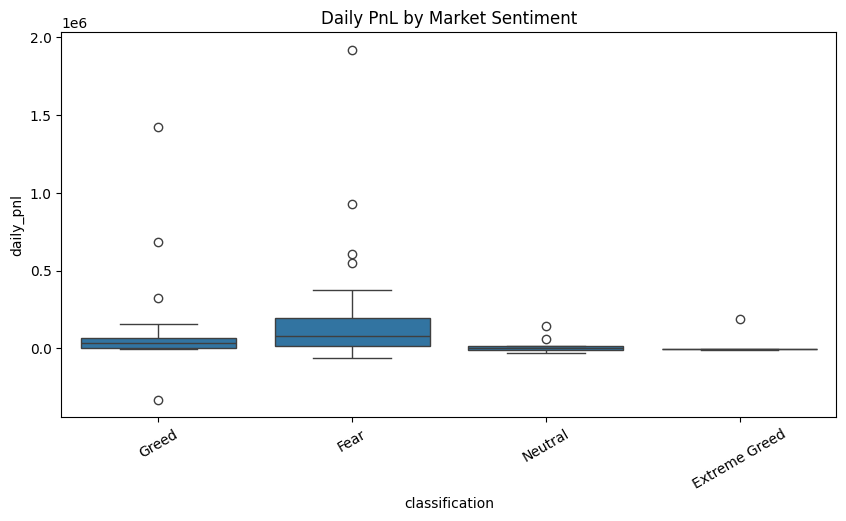

In [10]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=daily,
    x="classification",
    y="daily_pnl"
)

plt.title("Daily PnL by Market Sentiment")
plt.xticks(rotation=30)
plt.show()

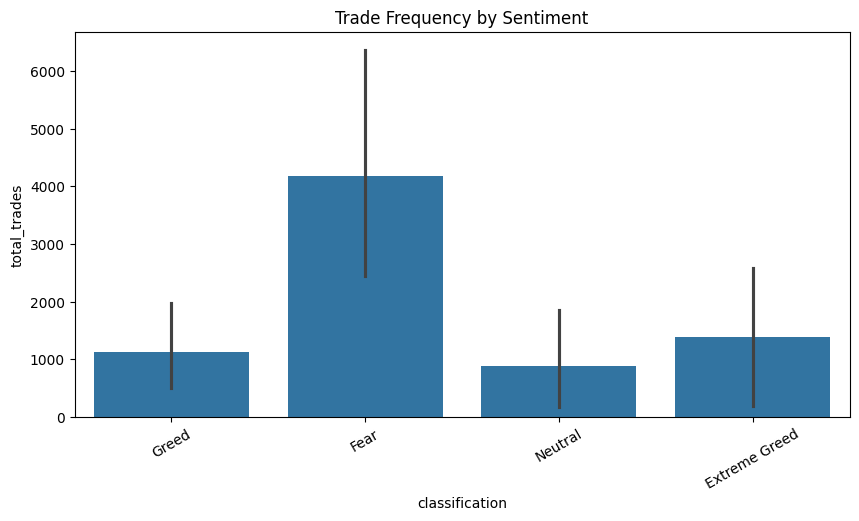

In [11]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=daily,
    x="classification",
    y="total_trades"
)

plt.title("Trade Frequency by Sentiment")
plt.xticks(rotation=30)
plt.show()

In [12]:
account_metrics = (
    df.groupby("Account")
    .agg(
        total_trades=("Trade ID","count"),
        total_pnl=("net_pnl","sum"),
        win_rate=("is_win","mean"),
        avg_trade_size=("Size USD","mean"),
        unique_days=("date","nunique")
    )
    .reset_index()
)

account_metrics["trades_per_day"] = (
    account_metrics["total_trades"] /
    account_metrics["unique_days"]
)

account_metrics.head()

,Account,total_trades,total_pnl,win_rate,avg_trade_size,unique_days,trades_per_day
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.592825e+06,0.359612,16159.576734,2,1909.0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3853,3.583909e+04,0.443031,1759.743439,2,1926.5
2,0x271b280974205ca63b716753467d5a371de622ab,1146,2.807403e+04,0.430192,10908.183944,3,382.0
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13266,1.300987e+05,0.438112,509.016502,2,6633.0
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3234,1.655207e+05,0.519790,3142.909573,2,1617.0


In [13]:
account_metrics["size_segment"] = pd.qcut(
    account_metrics["avg_trade_size"],
    q=3,
    labels=["Low","Medium","High"]
)

account_metrics["freq_segment"] = pd.qcut(
    account_metrics["trades_per_day"],
    q=3,
    labels=["Low","Medium","High"]
)

account_metrics.head()

,Account,total_trades,total_pnl,win_rate,avg_trade_size,unique_days,trades_per_day,size_segment,freq_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.592825e+06,0.359612,16159.576734,2,1909.0,High,Medium
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3853,3.583909e+04,0.443031,1759.743439,2,1926.5,Low,Medium
2,0x271b280974205ca63b716753467d5a371de622ab,1146,2.807403e+04,0.430192,10908.183944,3,382.0,High,Low
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13266,1.300987e+05,0.438112,509.016502,2,6633.0,Low,High
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3234,1.655207e+05,0.519790,3142.909573,2,1617.0,Medium,Medium


In [14]:
## Part C — Strategy Recommendations

In [15]:
print("""
Strategy 1:
During Fear days skilled traders should increase position sizes.
Inexperienced traders should reduce exposure.

Strategy 2:
During Greed markets trade frequency should be reduced
to avoid fee erosion and crowding effects.
""")


Strategy 1:
During Fear days skilled traders should increase position sizes.
Inexperienced traders should reduce exposure.

Strategy 2:
During Greed markets trade frequency should be reduced
to avoid fee erosion and crowding effects.



In [16]:
features = [
    "total_trades",
    "win_rate",
    "avg_trade_size"
]

account_metrics["target"] = account_metrics["total_pnl"] > 0

X = account_metrics[features]
y = account_metrics["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

print("Model accuracy:", rf.score(X_test,y_test))

Model accuracy: 1.0


In [17]:
features = [
    "total_trades",
    "win_rate",
    "avg_trade_size",
    "trades_per_day"
]

scaler = StandardScaler()
X = scaler.fit_transform(account_metrics[features])

kmeans = KMeans(n_clusters=4)

account_metrics["cluster"] = kmeans.fit_predict(X)

account_metrics.head()

,Account,total_trades,total_pnl,win_rate,avg_trade_size,unique_days,trades_per_day,size_segment,freq_segment,target,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.592825e+06,0.359612,16159.576734,2,1909.0,High,Medium,True,0
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3853,3.583909e+04,0.443031,1759.743439,2,1926.5,Low,Medium,True,2
2,0x271b280974205ca63b716753467d5a371de622ab,1146,2.807403e+04,0.430192,10908.183944,3,382.0,High,Low,True,2
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13266,1.300987e+05,0.438112,509.016502,2,6633.0,Low,High,True,3
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3234,1.655207e+05,0.519790,3142.909573,2,1617.0,Medium,Medium,True,2
